In [ ]:
pip install torch torchvision matplotlib


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load Dataset
train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# CNN Model
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 12 * 12, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 12 * 12)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Loop
epochs = 5

for epoch in range(epochs):
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

print("Training Complete!")


100%|██████████| 9.91M/9.91M [00:00<00:00, 39.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.10MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.92MB/s]


Epoch [1/5], Loss: 0.1285
Epoch [2/5], Loss: 0.0385
Epoch [3/5], Loss: 0.0241
Epoch [4/5], Loss: 0.0177
Epoch [5/5], Loss: 0.0126
Training Complete!


In [ ]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")


Test Accuracy: 98.84%


In [ ]:
torch.save(model.state_dict(), "mnist_cnn.pth")
print("Model saved successfully!")


Model saved successfully!


In [ ]:
model = CNN().to(device)
model.load_state_dict(torch.load("mnist_cnn.pth"))
model.eval()
print("Model loaded successfully!")


Model loaded successfully!


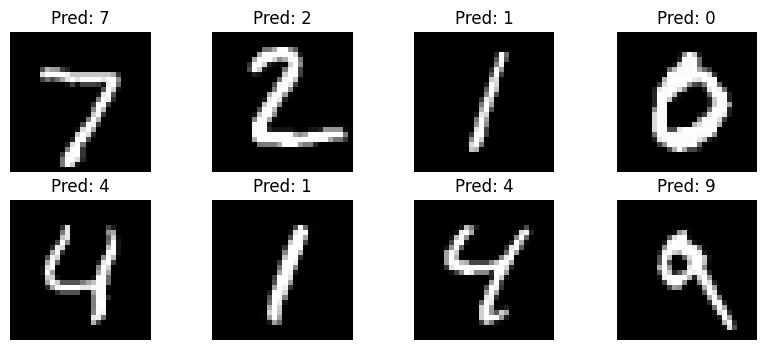

In [ ]:
import matplotlib.pyplot as plt

def visualize_predictions(model, test_loader):
    model.eval()
    images, labels = next(iter(test_loader))
    images, labels = images.to(device), labels.to(device)

    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

    images = images.cpu()

    plt.figure(figsize=(10,4))
    for i in range(8):
        plt.subplot(2,4,i+1)
        plt.imshow(images[i].squeeze(), cmap="gray")
        plt.title(f"Pred: {predicted[i].item()}")
        plt.axis("off")
    plt.show()

visualize_predictions(model, test_loader)


In [ ]:
pip install scikit-learn


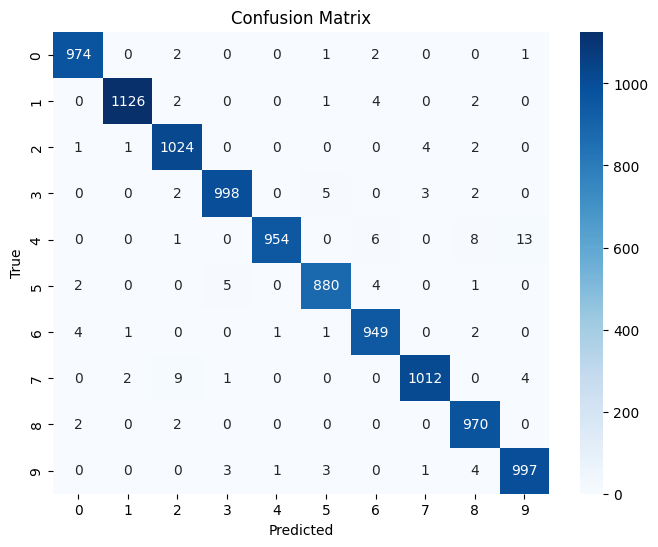

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


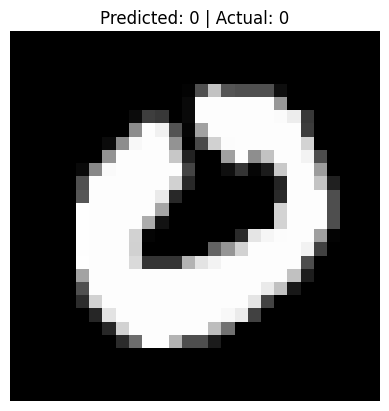

In [ ]:
def predict_single_image(model, dataset, index):
    model.eval()
    image, label = dataset[index]
    image = image.unsqueeze(0).to(device)

    output = model(image)
    _, predicted = torch.max(output, 1)

    plt.imshow(image.cpu().squeeze(), cmap="gray")
    plt.title(f"Predicted: {predicted.item()} | Actual: {label}")
    plt.axis("off")
    plt.show()

predict_single_image(model, test_dataset, index=25)
